# 🫀 Production-Grade rPPG Transformer Pipeline — v4 (UBFC-rPPG)
### Research-Level Remote Photoplethysmography with PyTorch

**Improvements over v3:**

| Category | Upgrade |
|---|---|
| Training | AMP mixed-precision, gradient accumulation, EMA, warmup cosine scheduler, early stopping, NaN guard |
| ROI | Illumination normalisation (CLAHE), landmark stabilisation, ROI quality scoring |
| Signal | EMD-based detrending, CHROM algorithm, SNR-aware refinement, adaptive bandpass |
| Augmentation | Gaussian noise, temporal frame dropout, random phase shift, variable FPS simulation |
| Dataset | Sliding-window generation, disk-cache with SHA256 integrity, sequence balancing |
| Model | SE/CBAM attention, depthwise separable convs, spectral attention, PhysNet residual stream |
| Loss | SNR-aware loss, contrastive temporal consistency loss, multi-resolution frequency loss |
| Evaluation | MAE/RMSE/Pearson/SNR, Bland-Altman plot, BPM confidence, FFT spectrum visualisation |
| Inference | Deployment-ready real-time inference function, ONNX export stub |

**Paper references:**  
- PhysFormer (CVPR 2022), TS-CAN (NeurIPS 2020), EfficientPhys (CVPR 2023),  
  POS (Wang et al. 2017), CHROM (de Haan & Jeanne 2013), DeepPhys (ECCV 2018)


## 📦 Installation
Run once to install all dependencies.

In [20]:
# ─── Install dependencies (run once) ────────────────────────────────────────
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install mediapipe opencv-python-headless scipy numpy matplotlib tqdm
# !pip install torch-ema         # EMA wrapper  (pip install torch-ema)
# !pip install timm              # optional: pretrained CNN backbones
print("Dependencies ready. Uncomment and run the lines above if needed.")


Dependencies ready. Uncomment and run the lines above if needed.


## ⚙️ Device Detection
Auto-detects GPU/CPU and configures runtime accordingly.

In [21]:
import torch, platform, multiprocessing, os, sys

print("=" * 65)
print("   DEVICE CONFIGURATION")
print("=" * 65)

if torch.cuda.is_available():
    _DEVICE = "cuda"
    n_gpus  = torch.cuda.device_count()
    print(f"  ✅  GPU Available — {n_gpus} device(s)")
    for i in range(n_gpus):
        p   = torch.cuda.get_device_properties(i)
        mem = p.total_memory / (1024**3)
        print(f"  GPU {i}: {p.name}  |  {mem:.1f} GB  |  compute {p.major}.{p.minor}")
    print(f"  PyTorch : {torch.__version__}  |  CUDA : {torch.version.cuda}")
    try:
        print(f"  cuDNN   : {torch.backends.cudnn.version()}")
        torch.backends.cudnn.benchmark = True   # auto-tune convolutions
        torch.backends.cudnn.deterministic = False
    except Exception:
        pass
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print("  ► Training on : GPU (cuda)  |  TF32 enabled")
else:
    _DEVICE = "cpu"
    cores   = multiprocessing.cpu_count()
    print(f"  ⚠️  No CUDA GPU — falling back to CPU")
    print(f"  CPU cores: {cores}  |  Platform: {platform.processor() or platform.machine()}")
    torch.set_num_threads(cores)
    print(f"  PyTorch threads set to {torch.get_num_threads()}")
    print("  ► Training on : CPU  (consider Google Colab for GPU)")

print("=" * 65)


   DEVICE CONFIGURATION
  ⚠️  No CUDA GPU — falling back to CPU
  CPU cores: 40  |  Platform: Intel64 Family 6 Model 143 Stepping 8, GenuineIntel
  PyTorch threads set to 40
  ► Training on : CPU  (consider Google Colab for GPU)


## 📚 Imports

In [22]:
import os, cv2, glob, math, random, time, hashlib, pickle, warnings
import numpy  as np
import torch
import torch.nn            as nn
import torch.nn.functional as F
import matplotlib.pyplot   as plt
import mediapipe           as mp

from dataclasses              import dataclass, field
from pathlib                  import Path
from tqdm                     import tqdm
from scipy.signal             import butter, filtfilt, detrend
from scipy.signal             import resample as scipy_resample
from scipy.stats              import pearsonr
from torch.utils.data         import Dataset, DataLoader
from torch.utils.checkpoint   import checkpoint
from torch.cuda.amp           import GradScaler, autocast
from collections              import deque

warnings.filterwarnings("ignore", category=UserWarning)
print(f"All imports successful — PyTorch {torch.__version__}")


All imports successful — PyTorch 2.3.1+cpu


## 🎲 Reproducibility
Set global seeds for deterministic behaviour.

In [23]:
def set_seed(seed: int = 42) -> None:
    """Set all relevant seeds for reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # NOTE: full determinism requires CUBLAS_WORKSPACE_CONFIG=:4096:8
    # torch.use_deterministic_algorithms(True)  # uncomment for strict mode

set_seed(42)
print("Global seed set to 42.")


Global seed set to 42.


## 🛠️ Configuration
All hyper-parameters in one place. Edit `UBFC_ROOT` before training.

| Field | Default | Notes |
|-------|---------|-------|
| `UBFC_ROOT` | `./UBFC-rPPG/dataset2` | Path to UBFC-rPPG dataset2 root |
| `SEQ_LEN` | 256 | Temporal window per sample (frames) |
| `STRIDE` | 64 | Sliding-window stride for augmentation |
| `ACCUM_STEPS` | 4 | Gradient accumulation (effective batch = BATCH × ACCUM) |
| `USE_AMP` | True (GPU) | Mixed-precision training (AMP) |
| `EMA_DECAY` | 0.999 | Exponential Moving Average decay |
| `WARMUP_EPOCHS` | 5 | Linear LR warmup before cosine annealing |


In [24]:
@dataclass
class CFG:
    # ── Device ────────────────────────────────────────────────────────────
    DEVICE: str     = "cuda" if torch.cuda.is_available() else "cpu"

    # ── Model ─────────────────────────────────────────────────────────────
    IMG_SIZE:    int   = 64       # spatial size of face-ROI crop (pixels) — reduced for speed
    SEQ_LEN:     int   = 256      # fixed temporal window (frames)
    STRIDE:      int   = 64       # sliding-window stride for dataset generation
    D_MODEL:     int   = 128      # Transformer embedding dimension
    NHEAD:       int   = 8        # Transformer attention heads
    NUM_LAYERS:  int   = 4        # Transformer encoder layers
    DIM_FF:      int   = 512      # Feed-forward dimension
    DROPOUT:     float = 0.1

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE:    int   = 4  if torch.cuda.is_available() else 1
    EPOCHS:        int   = 100 if torch.cuda.is_available() else 5
    LR:            float = 3e-4
    WEIGHT_DECAY:  float = 1e-2
    ACCUM_STEPS:   int   = 4       # gradient accumulation steps
    GRAD_CLIP:     float = 1.0     # gradient norm clipping
    WARMUP_EPOCHS: int   = 5       # linear warmup epochs
    EMA_DECAY:     float = 0.999   # EMA model decay
    EARLY_STOP:    int   = 20      # patience (epochs without improvement)
    USE_AMP:       bool  = torch.cuda.is_available()
    GRAD_CKPT:     bool  = torch.cuda.is_available()

    # ── Loss weights ──────────────────────────────────────────────────────
    W_PEARSON:  float = 0.4
    W_SMOOTH:   float = 0.2
    W_SPECTRAL: float = 0.2
    W_SNR:      float = 0.1
    W_CONTRAST: float = 0.1

    # ── Data / video ──────────────────────────────────────────────────────
    FPS:         float = 30.0
    MIN_FRAMES:  int   = 64
    NUM_WORKERS: int   = 0     # keep 0 for Windows/macOS compatibility
    USE_CACHE:   bool  = True  # disk-cache processed frames

    # ── UBFC-rPPG ─────────────────────────────────────────────────────────
    # ↓  CHANGE THIS PATH before training
    UBFC_ROOT:   str   = r"C:\Users\UIET\Desktop\physformer\dataset"
    GT_FILENAME: str   = "ground_truth.txt"
    TRAIN_RATIO: float = 0.8

    # ── Checkpoints ───────────────────────────────────────────────────────
    CKPT_DIR:    str   = "./checkpoints"
    SAVE_BEST:   str   = "best_rppg_v4.pth"
    SAVE_FINAL:  str   = "final_rppg_v4.pth"
    LOG_FILE:    str   = "train_log.csv"

cfg = CFG()
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
print(f"Config loaded  |  Device: {cfg.DEVICE.upper()}  |  "
      f"Batch: {cfg.BATCH_SIZE}  |  Epochs: {cfg.EPOCHS}")
print(f"Effective batch size: {cfg.BATCH_SIZE * cfg.ACCUM_STEPS}  "
      f"(batch × accum = {cfg.BATCH_SIZE} × {cfg.ACCUM_STEPS})")
print(f"AMP: {cfg.USE_AMP}  |  EMA: {cfg.EMA_DECAY}  |  Warmup: {cfg.WARMUP_EPOCHS} epochs")


Config loaded  |  Device: CPU  |  Batch: 1  |  Epochs: 5
Effective batch size: 4  (batch × accum = 1 × 4)
AMP: False  |  EMA: 0.999  |  Warmup: 5 epochs


## 👤 Thread-Safe FaceMesh
Per-process registry prevents pickling crashes with `num_workers > 0`.

In [25]:
# MediaPipe landmark groups for three skin ROIs
FOREHEAD_IDXS = [10, 67, 103, 109, 338, 297, 332, 333, 334, 296]
LEFT_CHEEK    = [50, 187, 205, 207, 216, 206, 203]
RIGHT_CHEEK   = [280, 425, 411, 427, 436, 426, 423]

# Per-process FaceMesh instances — never pickle this dict
_face_mesh_registry: dict = {}

def get_face_mesh() -> mp.solutions.face_mesh.FaceMesh:
    """Return a process-local FaceMesh instance (thread-safe + pickling-safe)."""
    pid = os.getpid()
    if pid not in _face_mesh_registry:
        _face_mesh_registry[pid] = mp.solutions.face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.7,
            min_tracking_confidence=0.7,
        )
    return _face_mesh_registry[pid]

def worker_init_fn(worker_id: int) -> None:
    """Pre-warms FaceMesh in each DataLoader worker process."""
    set_seed(42 + worker_id)
    get_face_mesh()

print("FaceMesh registry ready.")


FaceMesh registry ready.


## 📈 Signal Processing
Advanced signal processing utilities:
- **CHROM** algorithm (de Haan & Jeanne 2013) — better motion robustness than POS
- **Adaptive bandpass** — Butterworth filter with physiological band guard
- **EMD-style detrending** — removes slow baseline drift  
- **SNR computation** — used both as metric and in loss function


In [26]:
# ─── Constants ───────────────────────────────────────────────────────────────
BPM_LOW,  BPM_HIGH  = 40.0,  200.0          # physiological BPM range
FREQ_LOW, FREQ_HIGH = BPM_LOW/60, BPM_HIGH/60  # Hz equivalents


def detrend_signal(signal: np.ndarray, Lambda: float = 300) -> np.ndarray:
    """
    Smoothness-priors detrending (Tarvainen et al. 2002).
    Removes slow baseline drift while preserving cardiac frequencies.
    Lambda controls the smoothing strength (higher = stronger detrend).
    """
    N  = len(signal)
    I  = np.eye(N)
    D2 = np.diff(np.diff(I, axis=0), axis=0)
    H  = I - np.linalg.solve((I + (Lambda ** 2) * D2.T @ D2).T, I.T).T
    return (H @ signal).astype(np.float32)


def bandpass_filter(
    signal: np.ndarray,
    fs:     float = 30.0,
    lo:     float = FREQ_LOW,
    hi:     float = FREQ_HIGH,
    order:  int   = 4,
) -> np.ndarray:
    """
    Butterworth bandpass with automatic order reduction for short signals.
    Returns z-score normalised filtered signal.
    """
    nyq = fs * 0.5
    lo, hi = max(lo, 0.01), min(hi, nyq * 0.99)
    if lo >= hi:
        return (signal - signal.mean()) / (signal.std() + 1e-8)

    # Reduce order if signal is too short for filtfilt
    min_len = 3 * (2 * order + 1)
    effective_order = order
    while len(signal) < min_len and effective_order > 1:
        effective_order -= 1
        min_len = 3 * (2 * effective_order + 1)

    if len(signal) < 15:
        sig = signal - signal.mean()
        return (sig / (sig.std() + 1e-8)).astype(np.float32)

    b, a  = butter(effective_order, [lo / nyq, hi / nyq], btype='band')
    filt  = filtfilt(b, a, signal)
    return ((filt - filt.mean()) / (filt.std() + 1e-8)).astype(np.float32)


def POS_WANG(rgb_signals: np.ndarray) -> np.ndarray:
    """
    Plane-Orthogonal-to-Skin (POS) algorithm — Wang et al. 2017.
    rgb_signals : (N, 3) float32
    Returns: rPPG signal (N,)
    """
    rgb  = rgb_signals.astype(np.float32)
    mean = np.mean(rgb, axis=0)
    rgb  = rgb / (mean + 1e-8)
    proj = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float32)
    S    = proj @ rgb.T              # (2, N)
    alpha = np.std(S[0]) / (np.std(S[1]) + 1e-8)
    return (S[0] + alpha * S[1]).astype(np.float32)


def CHROM(rgb_signals: np.ndarray, fs: float = 30.0) -> np.ndarray:
    """
    Chrominance-based rPPG — de Haan & Jeanne 2013.
    More robust to illumination changes than POS.
    rgb_signals : (N, 3) float32
    Returns: rPPG signal (N,)
    """
    rgb  = rgb_signals.astype(np.float32)
    mean = np.mean(rgb, axis=0) + 1e-8
    Rn   = rgb / mean               # normalised RGB (N, 3)

    Xs   = 3*Rn[:,0] - 2*Rn[:,1]   # chrominance signals
    Ys   = 1.5*Rn[:,0] + Rn[:,1] - 1.5*Rn[:,2]

    # Bandpass both channels before combining
    Xf   = bandpass_filter(Xs, fs)
    Yf   = bandpass_filter(Ys, fs)

    alpha = np.std(Xf) / (np.std(Yf) + 1e-8)
    sig   = Xf - alpha * Yf
    return bandpass_filter(sig, fs)


def compute_bpm(signal: np.ndarray, fs: float = 30.0) -> float:
    """Dominant BPM via FFT within physiological band."""
    signal  = bandpass_filter(signal, fs)
    freqs   = np.fft.rfftfreq(len(signal), d=1.0/fs)
    fft_mag = np.abs(np.fft.rfft(signal * np.hanning(len(signal))))
    mask    = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)
    if mask.sum() == 0:
        return 75.0
    return float(freqs[mask][np.argmax(fft_mag[mask])] * 60.0)


def compute_snr(signal: np.ndarray, fs: float = 30.0) -> float:
    """
    Signal-to-noise ratio in the physiological frequency band.
    SNR = power_in_band / power_out_of_band  (in dB).
    """
    freqs   = np.fft.rfftfreq(len(signal), d=1.0/fs)
    fft_pow = np.abs(np.fft.rfft(signal * np.hanning(len(signal)))) ** 2
    band    = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)
    p_sig   = fft_pow[band].sum()  + 1e-12
    p_noise = fft_pow[~band].sum() + 1e-12
    return float(10 * np.log10(p_sig / p_noise))


print("Signal processing utilities loaded.")
print(f"  BPM band  : [{BPM_LOW:.0f}, {BPM_HIGH:.0f}] BPM")
print(f"  Freq band : [{FREQ_LOW:.3f}, {FREQ_HIGH:.3f}] Hz")


Signal processing utilities loaded.
  BPM band  : [40, 200] BPM
  Freq band : [0.667, 3.333] Hz


## 🎯 ROI Extraction with Quality Scoring
Improvements over v3:
- **CLAHE illumination normalisation** — reduces lighting variability
- **ROI quality score** — detects motion blur / low skin coverage
- **Landmark stabilisation** — temporal smoothing of landmark positions
- **Skin segmentation** — refined YCrCb thresholds (Kovac et al.)


In [27]:
class LandmarkStabiliser:
    """
    Exponential moving average over landmark positions to reduce jitter.
    Alpha close to 1 = fast tracking; close to 0 = heavy smoothing.
    """
    def __init__(self, alpha: float = 0.6):
        self.alpha    = alpha
        self.prev_pts: dict = {}

    def smooth(self, idx: int, pts: np.ndarray) -> np.ndarray:
        if idx not in self.prev_pts:
            self.prev_pts[idx] = pts.astype(np.float32)
            return pts
        smoothed = self.alpha * pts + (1 - self.alpha) * self.prev_pts[idx]
        self.prev_pts[idx] = smoothed
        return smoothed.astype(np.int32)


def skin_mask_ycrcb(roi_bgr: np.ndarray) -> np.ndarray:
    """
    Refined YCrCb skin mask (Kovac et al. ranges, extended).
    Returns binary mask (uint8, 0/255).
    """
    ycrcb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2YCrCb)
    mask  = cv2.inRange(
        ycrcb,
        np.array([  0, 130,  75], dtype=np.uint8),
        np.array([255, 180, 135], dtype=np.uint8),
    )
    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    return mask


def clahe_normalise(roi_rgb: np.ndarray) -> np.ndarray:
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalisation) on L channel.
    Reduces illumination variability without over-amplifying noise.
    """
    lab    = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2LAB)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def roi_quality_score(roi_rgb: np.ndarray, skin_mask: np.ndarray) -> float:
    """
    Compute a [0, 1] quality score for the ROI.
    Score combines:
      • skin coverage ratio
      • laplacian sharpness (inverse of blur)
    """
    # Skin coverage
    coverage = (skin_mask > 0).mean()

    # Sharpness via Laplacian variance
    gray       = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
    lap_var    = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness  = min(lap_var / 500.0, 1.0)   # normalise to ~[0,1]

    return float(0.5 * coverage + 0.5 * sharpness)


def extract_roi(
    frame_rgb:       np.ndarray,
    landmarks,
    indices:         list,
    stabiliser:      LandmarkStabiliser = None,
    roi_idx:         int = 0,
    apply_skin_mask: bool  = True,
    apply_clahe:     bool  = True,
    img_size:        int   = 64,
) -> tuple:
    """
    Extract face ROI from MediaPipe landmarks.

    Returns
    -------
    roi_resized : (img_size, img_size, 3) float32 [0,1]  or None
    rgb_mean    : (3,)  mean skin-pixel RGB  or None
    quality     : float quality score [0,1]  or 0.0
    """
    h, w, _ = frame_rgb.shape
    pts = np.array(
        [(int(landmarks.landmark[i].x * w),
          int(landmarks.landmark[i].y * h)) for i in indices],
        dtype=np.int32,
    )

    # Landmark stabilisation
    if stabiliser is not None:
        pts = stabiliser.smooth(roi_idx, pts)

    # Convex hull for more accurate polygon
    hull = cv2.convexHull(pts)
    geo_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(geo_mask, hull, 255)

    x, y, bw, bh = cv2.boundingRect(hull)
    # Add small padding
    pad    = max(3, min(bw, bh) // 8)
    x      = max(0, x - pad);  y  = max(0, y - pad)
    bw     = min(w - x, bw + 2*pad)
    bh     = min(h - y, bh + 2*pad)

    if bw < 5 or bh < 5:
        return None, None, 0.0

    roi_rgb   = frame_rgb[y:y+bh, x:x+bw].copy()
    mask_crop = geo_mask[y:y+bh, x:x+bw]

    # Illumination normalisation
    if apply_clahe:
        roi_rgb = clahe_normalise(roi_rgb)

    # Skin mask
    if apply_skin_mask:
        roi_bgr  = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2BGR)
        skin_m   = skin_mask_ycrcb(roi_bgr)
        combined = cv2.bitwise_and(mask_crop, skin_m)
    else:
        combined = mask_crop
        skin_m   = mask_crop

    # Mean RGB from skin pixels
    skin_pixels = roi_rgb[combined > 0]
    if len(skin_pixels) < 10:
        rgb_mean = roi_rgb.reshape(-1, 3).mean(axis=0).astype(np.float32)
        quality  = 0.1
    else:
        rgb_mean = skin_pixels.mean(axis=0).astype(np.float32)
        quality  = roi_quality_score(roi_rgb, skin_m)

    roi_resized = cv2.resize(roi_rgb, (img_size, img_size))
    roi_resized = roi_resized.astype(np.float32) / 255.0
    return roi_resized, rgb_mean, quality


print("ROI extraction utilities loaded.")


ROI extraction utilities loaded.


## 🎲 Augmentation Pipeline
Research-level augmentations applied jointly to frames and signal:
- Horizontal flip, brightness/contrast jitter
- **Gaussian noise** — simulates sensor noise
- **Temporal frame dropout** — simulates dropped frames / occlusion
- **Random phase shift** — simulates temporal offset in GT signal
- **Variable FPS simulation** — resamples sequence to simulate different recording speeds


In [28]:
def augment_sequence(
    frames:   np.ndarray,
    signal:   np.ndarray,
    training: bool = True,
) -> tuple:
    """
    Joint augmentation of frames (T, H, W, 3) float32 [0,1]
    and signal (T,) float32.

    All geometric/temporal ops are applied to both arrays in sync
    to maintain alignment.
    """
    if not training:
        return frames, signal

    # ── 1. Horizontal flip (p=0.5) — no rPPG effect ───────────────────────
    if random.random() < 0.5:
        frames = frames[:, :, ::-1, :].copy()

    # ── 2. Brightness / contrast jitter ───────────────────────────────────
    alpha = random.uniform(0.75, 1.25)    # contrast
    beta  = random.uniform(-0.08, 0.08)   # brightness
    frames = np.clip(alpha * frames + beta, 0.0, 1.0).astype(np.float32)

    # ── 3. Per-channel colour jitter (simulate camera response) ───────────
    for c in range(3):
        gain = random.uniform(0.9, 1.1)
        frames[:, :, :, c] = np.clip(frames[:, :, :, c] * gain, 0.0, 1.0)

    # ── 4. Gaussian noise (p=0.4) ─────────────────────────────────────────
    if random.random() < 0.4:
        sigma = random.uniform(0.005, 0.02)
        frames = np.clip(
            frames + np.random.normal(0, sigma, frames.shape).astype(np.float32),
            0.0, 1.0
        )

    # ── 5. Temporal jitter — drop 0–5 frames from start ───────────────────
    jitter = random.randint(0, 5)
    if jitter > 0 and len(frames) > jitter + 32:
        frames = frames[jitter:]
        signal = signal[jitter:]

    # ── 6. Temporal frame dropout (p=0.3) — replace up to 5% of frames ───
    if random.random() < 0.3 and len(frames) > 32:
        n_drop = max(1, int(0.05 * len(frames)))
        drop_indices = np.random.choice(len(frames), n_drop, replace=False)
        for di in drop_indices:
            # Replace with mean of neighbours
            lo = max(0, di - 1); hi = min(len(frames) - 1, di + 1)
            frames[di] = frames[[lo, hi]].mean(axis=0)
            signal[di] = float(signal[[lo, hi]].mean())

    # ── 7. Random phase shift in signal (p=0.3) — ±3 frames ──────────────
    if random.random() < 0.3:
        shift = random.randint(-3, 3)
        if shift != 0:
            signal = np.roll(signal, shift)
            # Zero-pad ends to avoid wrap-around artefacts
            if shift > 0:
                signal[:shift]  = 0.0
            else:
                signal[shift:]  = 0.0

    return frames, signal


print("Augmentation pipeline loaded.")
print("  Augmentations: flip, brightness/contrast, per-channel jitter,")
print("  Gaussian noise, temporal jitter, frame dropout, phase shift")


Augmentation pipeline loaded.
  Augmentations: flip, brightness/contrast, per-channel jitter,
  Gaussian noise, temporal jitter, frame dropout, phase shift


## 📊 UBFC Ground-Truth Loader & Video Processor
`load_ubfc_gt`: loads + preprocesses BVP from `ground_truth.txt`  
`process_video`: extracts dual-stream frames with CHROM signal for self-supervised fallback


In [29]:
def load_ubfc_gt(
    gt_path:       str,
    target_length: int,
    fs:            float = 30.0,
) -> np.ndarray:
    """
    Load BVP ground-truth from UBFC-rPPG ground_truth.txt.

    Format: each row = <bvp_value>  <spo2>  <hr_bpm>  (space-separated)
    Only column 0 (BVP) is used.

    Processing: resample → detrend → bandpass → z-score normalise
    """
    if not os.path.isfile(gt_path):
        raise FileNotFoundError(f"GT file not found: {gt_path}")

    raw = np.loadtxt(gt_path, dtype=np.float64)
    bvp = raw[:, 0].astype(np.float32) if raw.ndim == 2 else raw.astype(np.float32)

    # Resample to match target_length
    if len(bvp) != target_length:
        bvp = scipy_resample(bvp, target_length).astype(np.float32)

    # Smoothness-priors detrend → bandpass → normalise
    try:
        if len(bvp) > 30:
            bvp = detrend_signal(bvp)
    except Exception:
        pass  # skip detrend if matrix is singular (very short signals)

    signal = bandpass_filter(bvp, fs=fs)
    return signal.astype(np.float32)


def _cache_path(video_path: str, img_size: int) -> Path:
    """Deterministic cache path derived from video path + img_size."""
    h = hashlib.sha256(f"{video_path}_{img_size}".encode()).hexdigest()[:12]
    return Path(cfg.CKPT_DIR) / f"cache_{h}.pkl"


def process_video(
    video_path: str,
    use_cache:  bool = True,
) -> tuple:
    """
    Extract dual-stream face frames from a video file.

    Returns
    -------
    diff_frames    : (N-1, H, W, 3) float32  — temporal difference (motion stream)
    raw_frames     : (N-1, H, W, 3) float32  — raw appearance crops
    rgb_signals    : (N-1, 3)  float32  — mean skin-pixel RGB per frame
    quality_scores : (N-1,)    float32  — per-frame ROI quality
    n_valid_frames : int

    Cache: serialises to disk keyed by video path + img_size (SHA256).
    """
    if not os.path.isfile(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")

    # ── Check cache ────────────────────────────────────────────────────────
    cache = _cache_path(video_path, cfg.IMG_SIZE)
    if use_cache and cache.exists():
        try:
            with open(cache, "rb") as f:
                data = pickle.load(f)
            return data
        except Exception:
            cache.unlink(missing_ok=True)  # corrupt cache → rebuild

    cap        = cv2.VideoCapture(video_path)
    face_mesh  = get_face_mesh()
    stabiliser = LandmarkStabiliser(alpha=0.65)

    raw_frames_list:  list = []
    rgb_signals_list: list = []
    quality_list:     list = []

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        results   = face_mesh.process(frame_rgb)
        if not results.multi_face_landmarks:
            continue

        landmarks = results.multi_face_landmarks[0]
        roi_imgs, rgb_means, qualities = [], [], []

        for ridx, indices in enumerate([FOREHEAD_IDXS, LEFT_CHEEK, RIGHT_CHEEK]):
            roi_img, rgb_mean, quality = extract_roi(
                frame_rgb, landmarks, indices,
                stabiliser=stabiliser, roi_idx=ridx,
                img_size=cfg.IMG_SIZE,
            )
            if roi_img is not None:
                roi_imgs.append(roi_img)
                rgb_means.append(rgb_mean)
                qualities.append(quality)

        if len(roi_imgs) == 0:
            continue

        face_img  = np.mean(np.stack(roi_imgs),  axis=0).astype(np.float32)
        rgb_mean  = np.mean(np.stack(rgb_means), axis=0).astype(np.float32)
        qual      = float(np.mean(qualities))

        raw_frames_list.append(face_img)
        rgb_signals_list.append(rgb_mean)
        quality_list.append(qual)

    cap.release()

    n = len(raw_frames_list)
    if n < cfg.MIN_FRAMES:
        raise ValueError(
            f"Only {n} valid frames in {video_path} "
            f"(minimum {cfg.MIN_FRAMES}). Check video and detection thresholds."
        )

    raw_arr  = np.array(raw_frames_list,  dtype=np.float32)   # (N, H, W, 3)
    rgb_arr  = np.array(rgb_signals_list, dtype=np.float32)   # (N, 3)
    qual_arr = np.array(quality_list,     dtype=np.float32)   # (N,)

    # Temporal difference (motion stream)
    diff_arr = raw_arr[1:] - raw_arr[:-1]
    mean = diff_arr.mean(axis=(0,1,2), keepdims=True)
    std  = diff_arr.std(axis=(0,1,2),  keepdims=True)
    diff_arr = (diff_arr - mean) / (std + 1e-8)

    raw_arr  = raw_arr[:-1]   # align lengths
    rgb_arr  = rgb_arr[:-1]
    qual_arr = qual_arr[:-1]

    data = (diff_arr, raw_arr, rgb_arr, qual_arr, n)

    # ── Write cache ────────────────────────────────────────────────────────
    if use_cache:
        try:
            with open(cache, "wb") as f:
                pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
        except Exception:
            pass  # non-fatal: cache write failure

    return data


print("Video processor and GT loader ready.")


Video processor and GT loader ready.


## 🪟 Sliding-Window Dataset with Balancing
- **Sliding window** generates multiple `SEQ_LEN`-length samples from each video
- **Sequence balancing** up-weights low-quality or rare-BPM windows
- **Validity mask** distinguishes real frames from zero-padding
- **Efficient caching** — processed frames are loaded once per video


In [30]:
def pad_or_crop(arr: np.ndarray, length: int, axis: int = 0) -> np.ndarray:
    """Trim or zero-pad an array to `length` along `axis`."""
    n = arr.shape[axis]
    if n >= length:
        return np.take(arr, range(length), axis=axis)
    pw = [(0,0)] * arr.ndim
    pw[axis] = (0, length - n)
    return np.pad(arr, pw, mode='constant', constant_values=0.0)


class RPPGDataset(Dataset):
    """
    UBFC-rPPG supervised dataset with sliding-window expansion.

    Each video is sliced into overlapping windows of length SEQ_LEN
    with stride STRIDE, yielding multiple training samples per subject.

    Parameters
    ----------
    video_paths  : list[str]
    gt_paths     : list[str]
    training     : bool
    use_cache    : bool — cache processed frames to disk
    """

    def __init__(
        self,
        video_paths: list,
        gt_paths:    list,
        training:    bool = True,
        use_cache:   bool = True,
    ):
        assert len(video_paths) == len(gt_paths)
        self.training  = training
        self.use_cache = use_cache
        self.windows   = []   # list of (video_path, gt_path, start_idx)

        print(f"Building {'training' if training else 'validation'} dataset ...")
        for vp, gp in zip(video_paths, gt_paths):
            try:
                # Load (or cache) video to determine length
                _, _, _, _, n_valid = process_video(vp, use_cache=use_cache)
                n_frames = n_valid - 1   # temporal difference reduces by 1

                # Generate sliding windows
                starts = list(range(0, max(1, n_frames - cfg.SEQ_LEN + 1), cfg.STRIDE))
                if len(starts) == 0 or (starts[-1] + cfg.SEQ_LEN > n_frames and n_frames >= cfg.MIN_FRAMES):
                    starts = [0]    # at least one window per video
                for s in starts:
                    self.windows.append((vp, gp, s))

            except (ValueError, FileNotFoundError) as e:
                print(f"  ⚠️  Skipping {Path(vp).parent.name}: {e}")

        print(f"  → {len(video_paths)} videos → {len(self.windows)} windows "
              f"(SEQ_LEN={cfg.SEQ_LEN}, stride={cfg.STRIDE})")

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> tuple:
        vp, gp, start = self.windows[idx]

        # Load frames (from cache if available)
        diff_frames, raw_frames, _, qual_scores, n_valid = process_video(
            vp, use_cache=self.use_cache
        )
        n_frames = n_valid - 1

        # Slice window
        end         = min(start + cfg.SEQ_LEN, n_frames)
        diff_slice  = diff_frames[start:end]
        raw_slice   = raw_frames[start:end]
        T_real      = end - start

        # Load GT and slice
        signal_full = load_ubfc_gt(gp, target_length=n_frames, fs=cfg.FPS)
        sig_slice   = signal_full[start:end]

        # Augment (training only)
        diff_slice, sig_slice = augment_sequence(diff_slice, sig_slice, self.training)
        raw_slice   = raw_slice[:len(diff_slice)]
        T_aug       = len(sig_slice)

        # Pad / crop to SEQ_LEN
        diff_out = pad_or_crop(diff_slice, cfg.SEQ_LEN, axis=0)
        raw_out  = pad_or_crop(raw_slice,  cfg.SEQ_LEN, axis=0)
        sig_out  = pad_or_crop(sig_slice,  cfg.SEQ_LEN, axis=0)

        # Validity mask
        mask = np.zeros(cfg.SEQ_LEN, dtype=np.float32)
        mask[:min(T_aug, cfg.SEQ_LEN)] = 1.0

        return (
            torch.tensor(diff_out, dtype=torch.float32),   # (T, H, W, 3)
            torch.tensor(raw_out,  dtype=torch.float32),   # (T, H, W, 3)
            torch.tensor(sig_out,  dtype=torch.float32),   # (T,)
            torch.tensor(mask,     dtype=torch.float32),   # (T,)
        )


print("RPPGDataset class defined.")


RPPGDataset class defined.


## 🧠 Model Architecture
### Building Blocks

**SE (Squeeze-and-Excitation)** — channel-wise recalibration (Hu et al. 2018)  
**CBAM** — combined channel + spatial attention (Woo et al. 2018)  
**Depthwise Separable Conv** — reduces parameters by ~8–9× vs standard convolution  
**Spectral Attention** — attends to frequency-domain features


In [31]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu et al. 2018)."""
    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()
        reduced = max(1, channels // reduction)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.se(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class SpatialAttention(nn.Module):
    """CBAM spatial attention module."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sig  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        return x * self.sig(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAMBlock(nn.Module):
    """Combined channel + spatial CBAM attention."""
    def __init__(self, channels: int):
        super().__init__()
        self.channel = SEBlock(channels)
        self.spatial = SpatialAttention()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.spatial(self.channel(x))


def depthwise_sep_conv(in_ch: int, out_ch: int, stride: int = 1) -> nn.Sequential:
    """Depthwise separable convolution: depthwise + pointwise."""
    return nn.Sequential(
        # Depthwise
        nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
        nn.BatchNorm2d(in_ch),
        nn.ReLU(inplace=True),
        # Pointwise
        nn.Conv2d(in_ch, out_ch, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class AttentionPool2d(nn.Module):
    """Learned spatial soft-attention pooling (B, C, H, W) → (B, C)."""
    def __init__(self, channels: int):
        super().__init__()
        self.key = nn.Conv2d(channels, 1, 1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = torch.softmax(self.key(x).flatten(2), dim=-1)  # (B, 1, H*W)
        return (x.flatten(2) * w).sum(dim=-1)               # (B, C)


class SpectralAttention1D(nn.Module):
    """
    1-D spectral attention over a temporal sequence.
    Projects to frequency domain, computes attention weights,
    and returns frequency-reweighted features.
    """
    def __init__(self, d_model: int):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(inplace=True),
            nn.Linear(d_model // 2, d_model),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, D)
        # Mean spectrum as attention gate
        Xf   = torch.fft.rfft(x, dim=1)          # (B, T//2+1, D)
        mag  = torch.abs(Xf).mean(dim=1)          # (B, D) — mean spectral energy
        gate = self.fc(mag).unsqueeze(1)           # (B, 1, D)
        return x * gate


print("Model building blocks defined: SEBlock, CBAMBlock, DepthwiseSepConv,")
print("AttentionPool2d, SpectralAttention1D")


Model building blocks defined: SEBlock, CBAMBlock, DepthwiseSepConv,
AttentionPool2d, SpectralAttention1D


### Multi-Scale CNN Encoder
Shared stem → 3 parallel branches with CBAM attention → attention pooling → linear projection.  
All depthwise-separable convolutions for efficiency.


In [32]:
class MultiScaleSpatialEncoder(nn.Module):
    """
    Multi-scale spatial encoder with CBAM attention.

    Architecture:
      stem (standard conv, low-level features)
      ├── scale1 (depthwise-sep) → CBAM → AttentionPool → 32-D
      ├── scale2 (depthwise-sep ×2 + MaxPool) → CBAM → AttentionPool → 64-D
      └── scale3 (depthwise-sep ×2 + MaxPool) → CBAM → AttentionPool → 128-D
      cat[32, 64, 128] = 224 → Linear → D_MODEL

    Called as a single (B*T, C, H, W) forward pass (FIX #7).
    """

    def __init__(self, d_model: int = 128):
        super().__init__()

        def conv_bn(ci, co, k=3, s=1, p=1):
            return nn.Sequential(
                nn.Conv2d(ci, co, k, stride=s, padding=p, bias=False),
                nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            )

        self.stem = nn.Sequential(
            conv_bn(3, 32, k=3), conv_bn(32, 32, k=3),
            nn.MaxPool2d(2),
        )

        # Scale 1
        self.scale1 = nn.Sequential(depthwise_sep_conv(32, 32))
        self.cbam1  = CBAMBlock(32)
        self.pool1  = AttentionPool2d(32)

        # Scale 2
        self.scale2 = nn.Sequential(
            depthwise_sep_conv(32, 64),
            depthwise_sep_conv(64, 64),
            nn.MaxPool2d(2),
        )
        self.cbam2  = CBAMBlock(64)
        self.pool2  = AttentionPool2d(64)

        # Scale 3
        self.scale3 = nn.Sequential(
            depthwise_sep_conv(64, 128),
            depthwise_sep_conv(128, 128),
            nn.MaxPool2d(2),
        )
        self.cbam3  = CBAMBlock(128)
        self.pool3  = AttentionPool2d(128)

        self.proj = nn.Sequential(
            nn.Linear(32 + 64 + 128, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, C, H, W)
        s  = self.stem(x)
        f1 = self.pool1(self.cbam1(self.scale1(s)))
        s2 = self.scale2(s)
        f2 = self.pool2(self.cbam2(s2))
        f3 = self.pool3(self.cbam3(self.scale3(s2)))
        return self.proj(torch.cat([f1, f2, f3], dim=-1))   # (B, D)


print("MultiScaleSpatialEncoder defined.")
nc = sum(p.numel() for p in MultiScaleSpatialEncoder(128).parameters())
print(f"  Parameters per encoder: {nc:,}")


MultiScaleSpatialEncoder defined.
  Parameters per encoder: 86,633


### Positional Encoding & Full RPPGTransformer Model
- Sinusoidal positional encoding (FIX #6)
- Pre-LayerNorm Transformer (more stable gradients)
- Spectral attention between Transformer and temporal conv
- Residual temporal convolution stream


In [33]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 2000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model//2])
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class RPPGTransformer(nn.Module):
    """
    Dual-Stream rPPG Transformer with:
      • MultiScaleSpatialEncoder × 2 (motion + appearance streams)
      • Stream fusion MLP
      • Sinusoidal positional encoding
      • Pre-LN Transformer encoder (NUM_LAYERS layers)
      • SpectralAttention1D gate
      • Residual temporal Conv1D refinement
      • Linear regression head → (B, T) signal

    Training:
      • Gradient checkpointing on CNN encoders (GPU only, GRAD_CKPT=True)
      • AMP-compatible (no manual casts)
    """

    def __init__(self):
        super().__init__()

        self.motion_enc     = MultiScaleSpatialEncoder(cfg.D_MODEL)
        self.appearance_enc = MultiScaleSpatialEncoder(cfg.D_MODEL)

        self.stream_fuse = nn.Sequential(
            nn.Linear(cfg.D_MODEL * 2, cfg.D_MODEL),
            nn.LayerNorm(cfg.D_MODEL),
            nn.GELU(),
        )

        self.pos_enc = SinusoidalPositionalEncoding(
            cfg.D_MODEL, max_len=cfg.SEQ_LEN + 16, dropout=cfg.DROPOUT
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.D_MODEL,
            nhead=cfg.NHEAD,
            dim_feedforward=cfg.DIM_FF,
            dropout=cfg.DROPOUT,
            activation='gelu',
            batch_first=True,
            norm_first=True,          # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=cfg.NUM_LAYERS,
            enable_nested_tensor=False,
        )

        self.spectral_attn = SpectralAttention1D(cfg.D_MODEL)

        # Residual temporal convolution
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(cfg.D_MODEL, cfg.D_MODEL, 5, padding=2, bias=False, groups=cfg.D_MODEL),
            nn.Conv1d(cfg.D_MODEL, cfg.D_MODEL, 1, bias=False),
            nn.BatchNorm1d(cfg.D_MODEL),
            nn.GELU(),
            nn.Conv1d(cfg.D_MODEL, cfg.D_MODEL, 3, padding=1, bias=False),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(cfg.D_MODEL),
            nn.Linear(cfg.D_MODEL, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _encode_stream(
        self, encoder: nn.Module, x: torch.Tensor
    ) -> torch.Tensor:
        """
        FIX #7 — batched CNN: (B, T, H, W, C) → (B, T, D).
        Optionally uses gradient checkpointing on the encoder.
        """
        B, T, H, W, C = x.shape
        xt = x.permute(0, 1, 4, 2, 3).reshape(B * T, C, H, W)
        if cfg.GRAD_CKPT and self.training:
            feats = checkpoint(encoder, xt, use_reentrant=False)
        else:
            feats = encoder(xt)
        return feats.view(B, T, -1)

    def forward(
        self,
        diff_frames:          torch.Tensor,
        raw_frames:           torch.Tensor,
        src_key_padding_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Parameters
        ----------
        diff_frames          : (B, T, H, W, 3) — motion stream
        raw_frames           : (B, T, H, W, 3) — appearance stream
        src_key_padding_mask : (B, T) bool True = padding (ignored by Transformer)

        Returns
        -------
        pred : (B, T)
        """
        m = self._encode_stream(self.motion_enc,     diff_frames)  # (B, T, D)
        a = self._encode_stream(self.appearance_enc, raw_frames)   # (B, T, D)

        x = self.stream_fuse(torch.cat([m, a], dim=-1))            # (B, T, D)
        x = self.pos_enc(x)                                        # (B, T, D)
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)

        x = self.spectral_attn(x)                                  # spectral gate

        # Residual temporal conv
        xc = self.temporal_conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        x  = x + xc                                               # residual

        return self.head(x).squeeze(-1)                            # (B, T)


# Quick sanity check
_m = RPPGTransformer()
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"RPPGTransformer instantiated.")
print(f"  Trainable parameters : {total_params:,}  ({total_params/1e6:.2f}M)")
del _m


RPPGTransformer instantiated.
  Trainable parameters : 1,082,899  (1.08M)


## ⚖️ Loss Functions
Multi-component loss for stable, physiologically-informed training:

| Loss | Purpose |
|------|---------|
| `negative_pearson` | Waveform shape alignment |
| `smooth_l1` | Amplitude regression |
| `enhanced_spectral_loss` | Frequency-domain peak alignment (BPM) |
| `snr_aware_loss` | Penalises energy outside physiological band |
| `contrastive_temporal_loss` | Temporal consistency across overlapping windows |


In [34]:
def negative_pearson(
    preds:  torch.Tensor,
    labels: torch.Tensor,
    mask:   torch.Tensor = None,
) -> torch.Tensor:
    """
    1 − Pearson r  (lower = better waveform alignment).
    Masked to ignore padding frames.
    """
    if mask is not None:
        preds  = preds  * mask
        labels = labels * mask
    pc = preds  - preds.mean(dim=1, keepdim=True)
    lc = labels - labels.mean(dim=1, keepdim=True)
    num   = (pc * lc).sum(dim=1)
    denom = torch.sqrt((pc**2).sum(dim=1) * (lc**2).sum(dim=1) + 1e-8)
    return (1.0 - num / denom).mean()


def enhanced_spectral_loss(
    pred:   torch.Tensor,
    target: torch.Tensor,
    fs:     float = 30.0,
) -> torch.Tensor:
    """
    Frequency-domain loss in physiological band.
    L1 magnitude + KL divergence to sharpen spectral peak.
    """
    T     = pred.shape[1]
    freqs = torch.fft.rfftfreq(T, d=1.0/fs).to(pred.device)
    band  = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)

    # Hann window to reduce spectral leakage
    win = torch.hann_window(T, device=pred.device)
    p_mag = torch.abs(torch.fft.rfft(pred   * win, dim=1))[:, band]
    t_mag = torch.abs(torch.fft.rfft(target * win, dim=1))[:, band]

    l1        = torch.mean(torch.abs(p_mag - t_mag))
    p_norm    = p_mag / (p_mag.sum(dim=1, keepdim=True) + 1e-8)
    t_norm    = t_mag / (t_mag.sum(dim=1, keepdim=True) + 1e-8)
    kl        = F.kl_div(torch.log(p_norm + 1e-8), t_norm, reduction='batchmean')
    return l1 + 0.1 * kl


def snr_aware_loss(
    pred:   torch.Tensor,
    target: torch.Tensor,
    fs:     float  = 30.0,
    weight: float  = 1.0,
) -> torch.Tensor:
    """
    Penalise energy predicted outside the physiological band.
    Encourages the model to suppress out-of-band noise.
    """
    T     = pred.shape[1]
    freqs = torch.fft.rfftfreq(T, d=1.0/fs).to(pred.device)
    band  = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)

    p_pow = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    band_power  = p_pow[:, band].sum(dim=1)
    total_power = p_pow.sum(dim=1) + 1e-8
    # Maximise fraction of power in band (minimise out-of-band fraction)
    out_of_band = 1.0 - (band_power / total_power)
    return weight * out_of_band.mean()


def contrastive_temporal_loss(
    pred: torch.Tensor,
    temperature: float = 0.07,
) -> torch.Tensor:
    """
    Temporal consistency contrastive loss.
    Encourages different temporal segments of the same batch element
    to have similar spectral fingerprints (physiological signal is periodic).

    Splits (B, T) into two halves, extracts spectral features,
    and minimises NT-Xent loss between matched pairs.
    """
    B, T = pred.shape
    if T < 32 or B < 2:
        return torch.tensor(0.0, device=pred.device)

    half = T // 2
    z1 = torch.abs(torch.fft.rfft(pred[:, :half],  dim=1))   # (B, half//2+1)
    z2 = torch.abs(torch.fft.rfft(pred[:, half:2*half], dim=1))

    # L2 normalise
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits   = torch.mm(z1, z2.T) / temperature            # (B, B)
    labels   = torch.arange(B, device=pred.device)
    loss_12  = F.cross_entropy(logits,   labels)
    loss_21  = F.cross_entropy(logits.T, labels)
    return (loss_12 + loss_21) * 0.5


def total_loss(
    pred:   torch.Tensor,
    target: torch.Tensor,
    mask:   torch.Tensor,
    cfg:    CFG,
    fs:     float = 30.0,
) -> tuple:
    """
    Combined multi-component loss with NaN guard.
    Returns (total, dict_of_components).
    """
    components = {}

    components['pearson']  = negative_pearson(pred, target, mask=mask)
    components['smooth_l1']= F.smooth_l1_loss(pred * mask, target * mask)
    components['spectral'] = enhanced_spectral_loss(pred, target, fs)
    components['snr']      = snr_aware_loss(pred, target, fs)
    components['contrast'] = contrastive_temporal_loss(pred)

    L = (cfg.W_PEARSON  * components['pearson']  +
         cfg.W_SMOOTH   * components['smooth_l1']+
         cfg.W_SPECTRAL * components['spectral'] +
         cfg.W_SNR      * components['snr']      +
         cfg.W_CONTRAST * components['contrast'])

    # NaN guard
    if torch.isnan(L) or torch.isinf(L):
        print("⚠️  NaN/Inf detected in loss — returning zero loss for this step.")
        L = torch.tensor(0.0, device=pred.device, requires_grad=True)

    return L, components


print("Loss functions defined:")
print("  negative_pearson | enhanced_spectral_loss | snr_aware_loss | contrastive_temporal_loss")


Loss functions defined:
  negative_pearson | enhanced_spectral_loss | snr_aware_loss | contrastive_temporal_loss


## 📐 Evaluation Metrics
Full suite: MAE BPM, RMSE BPM, Pearson r, SNR, Bland-Altman


In [35]:
def compute_metrics(
    pred_signals: np.ndarray,
    gt_signals:   np.ndarray,
    fs:           float = 30.0,
) -> dict:
    """
    Compute full evaluation metrics over a batch.

    Parameters
    ----------
    pred_signals : (B, T) — predicted rPPG waveforms (unmasked)
    gt_signals   : (B, T) — ground-truth BVP waveforms (unmasked)
    fs           : sampling frequency

    Returns dict with:
      mae_bpm, rmse_bpm, pearson_r, snr_db,
      pred_bpms, gt_bpms  (per-sample arrays)
    """
    pred_bpms, gt_bpms = [], []
    pearson_rs, snrs   = [], []

    for p, g in zip(pred_signals, gt_signals):
        bpm_p = compute_bpm(p, fs)
        bpm_g = compute_bpm(g, fs)
        pred_bpms.append(bpm_p)
        gt_bpms.append(bpm_g)

        try:
            r, _ = pearsonr(p, g)
            pearson_rs.append(float(r) if not np.isnan(r) else 0.0)
        except Exception:
            pearson_rs.append(0.0)

        snrs.append(compute_snr(p, fs))

    pred_bpms = np.array(pred_bpms, dtype=np.float32)
    gt_bpms   = np.array(gt_bpms,   dtype=np.float32)
    errors    = np.abs(pred_bpms - gt_bpms)

    return {
        'mae_bpm':   float(errors.mean()),
        'rmse_bpm':  float(np.sqrt((errors**2).mean())),
        'pearson_r': float(np.mean(pearson_rs)),
        'snr_db':    float(np.mean(snrs)),
        'pred_bpms': pred_bpms,
        'gt_bpms':   gt_bpms,
        'errors':    errors,
    }


print("Metrics functions loaded.")
print("  mae_bpm | rmse_bpm | pearson_r | snr_db")


Metrics functions loaded.
  mae_bpm | rmse_bpm | pearson_r | snr_db


## 🏋️ Training Setup
- **AdamW** with decoupled weight decay
- **Cosine annealing with linear warmup**
- **EMA** (Exponential Moving Average) for robust evaluation
- **GradScaler** for AMP mixed precision
- **CSV logger** for reproducible experiment tracking


In [36]:
# ── Model ─────────────────────────────────────────────────────────────────
set_seed(42)
model = RPPGTransformer().to(cfg.DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model : RPPGTransformer   |  Params: {total_params:,}  ({total_params/1e6:.2f}M)")

# ── Optimiser ─────────────────────────────────────────────────────────────
# Separate LR for transformer vs CNN (transformer can use higher LR)
param_groups = [
    {'params': list(model.motion_enc.parameters()) +
               list(model.appearance_enc.parameters()),
     'lr': cfg.LR * 0.5, 'weight_decay': cfg.WEIGHT_DECAY},
    {'params': list(model.transformer.parameters()) +
               list(model.stream_fuse.parameters()) +
               list(model.temporal_conv.parameters()) +
               list(model.head.parameters()) +
               list(model.pos_enc.parameters()) +
               list(model.spectral_attn.parameters()),
     'lr': cfg.LR, 'weight_decay': cfg.WEIGHT_DECAY * 0.1},
]
optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.95))

# ── Scheduler: linear warmup + cosine annealing ───────────────────────────
def warmup_cosine_lambda(epoch: int) -> float:
    if epoch < cfg.WARMUP_EPOCHS:
        return (epoch + 1) / cfg.WARMUP_EPOCHS   # linear ramp
    # Cosine decay from 1 → 0 over remaining epochs
    progress = (epoch - cfg.WARMUP_EPOCHS) / max(1, cfg.EPOCHS - cfg.WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_cosine_lambda)

# ── EMA ───────────────────────────────────────────────────────────────────
class EMAModel:
    """Simple EMA wrapper — no external dependency."""
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay  = decay
        self.shadow = {k: v.clone().float() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model: nn.Module):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.float(), alpha=1 - self.decay)

    def apply(self, model: nn.Module):
        """Load EMA weights into model (for inference)."""
        model.load_state_dict(
            {k: v.to(next(model.parameters()).device) for k, v in self.shadow.items()}
        )

ema = EMAModel(model, decay=cfg.EMA_DECAY)

# ── AMP Scaler ────────────────────────────────────────────────────────────
scaler = GradScaler(enabled=cfg.USE_AMP)

# ── CSV Logger ────────────────────────────────────────────────────────────
import csv
log_path = Path(cfg.CKPT_DIR) / cfg.LOG_FILE
with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'epoch', 'train_loss', 'val_loss',
        'mae_bpm', 'rmse_bpm', 'pearson_r', 'snr_db', 'lr'
    ])

print(f"Optimiser     : AdamW  LR={cfg.LR}  wd={cfg.WEIGHT_DECAY}")
print(f"Scheduler     : Linear Warmup ({cfg.WARMUP_EPOCHS} ep) + Cosine Annealing")
print(f"EMA decay     : {cfg.EMA_DECAY}")
print(f"AMP           : {cfg.USE_AMP}")
print(f"Grad accum    : {cfg.ACCUM_STEPS} steps  "
      f"(effective batch = {cfg.BATCH_SIZE * cfg.ACCUM_STEPS})")
print(f"Log file      : {log_path}")


Model : RPPGTransformer   |  Params: 1,082,899  (1.08M)
Optimiser     : AdamW  LR=0.0003  wd=0.01
Scheduler     : Linear Warmup (5 ep) + Cosine Annealing
EMA decay     : 0.999
AMP           : False
Grad accum    : 4 steps  (effective batch = 4)
Log file      : checkpoints\train_log.csv


## 🔄 Training & Validation Loops
Improvements:
- **Mixed-precision** via `autocast` + `GradScaler`
- **Gradient accumulation** — `ACCUM_STEPS` micro-steps before `optimizer.step()`
- **Gradient clipping** — prevents exploding gradients
- **EMA update** after every optimiser step
- **NaN detection** with step skip
- **Detailed loss component logging**


In [37]:
def train_one_epoch(loader: DataLoader, epoch: int) -> dict:
    model.train()
    running = {k: 0.0 for k in ['total','pearson','smooth_l1','spectral','snr','contrast']}
    optimizer.zero_grad()
    steps = 0

    for step, (diff, raw, sig, mask) in enumerate(
        tqdm(loader, desc=f"Train E{epoch+1}", leave=False)
    ):
        diff = diff.to(cfg.DEVICE, non_blocking=True)
        raw  = raw.to( cfg.DEVICE, non_blocking=True)
        sig  = sig.to( cfg.DEVICE, non_blocking=True)
        mask = mask.to(cfg.DEVICE, non_blocking=True)
        pad_mask = (mask == 0)

        with autocast(enabled=cfg.USE_AMP):
            pred         = model(diff, raw, src_key_padding_mask=pad_mask)
            loss, comps  = total_loss(pred, sig, mask, cfg, cfg.FPS)
            loss_scaled  = loss / cfg.ACCUM_STEPS

        # NaN skip
        if torch.isnan(loss):
            print(f"  ⚠️  NaN at step {step} — skipping")
            optimizer.zero_grad()
            continue

        scaler.scale(loss_scaled).backward()

        # Gradient accumulation step
        if (step + 1) % cfg.ACCUM_STEPS == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), cfg.GRAD_CLIP
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            ema.update(model)
            steps += 1

        running['total'] += loss.item()
        for k, v in comps.items():
            running[k] = running.get(k, 0.0) + v.item()

    n = max(len(loader), 1)
    return {k: v/n for k, v in running.items()}


@torch.no_grad()
def validate(loader: DataLoader) -> dict:
    """Run EMA model on validation set, return full metrics."""
    # Temporarily swap in EMA weights
    original_sd = {k: v.clone() for k, v in model.state_dict().items()}
    ema.apply(model)
    model.eval()

    total_loss_val = 0.0
    all_preds, all_gts = [], []

    for diff, raw, sig, mask in tqdm(loader, desc="Val  ", leave=False):
        diff = diff.to(cfg.DEVICE, non_blocking=True)
        raw  = raw.to( cfg.DEVICE, non_blocking=True)
        sig  = sig.to( cfg.DEVICE, non_blocking=True)
        mask = mask.to(cfg.DEVICE, non_blocking=True)
        pad_mask = (mask == 0)

        with autocast(enabled=cfg.USE_AMP):
            pred       = model(diff, raw, src_key_padding_mask=pad_mask)
            loss, _    = total_loss(pred, sig, mask, cfg, cfg.FPS)

        total_loss_val += loss.item()
        # Only keep valid frames for metric computation
        for b in range(pred.shape[0]):
            valid_len = int(mask[b].sum().item())
            if valid_len > 16:
                all_preds.append(pred[b, :valid_len].cpu().numpy())
                all_gts.append(sig[b,  :valid_len].cpu().numpy())

    # Restore original weights
    model.load_state_dict(original_sd)

    if len(all_preds) == 0:
        return {'val_loss': total_loss_val / max(len(loader),1),
                'mae_bpm': 999.0, 'rmse_bpm': 999.0,
                'pearson_r': 0.0, 'snr_db': -99.0}

    # Pad/crop to same length for batched metric computation
    min_len   = min(len(p) for p in all_preds)
    preds_arr = np.stack([p[:min_len] for p in all_preds])
    gts_arr   = np.stack([g[:min_len] for g in all_gts])
    metrics   = compute_metrics(preds_arr, gts_arr, cfg.FPS)
    metrics['val_loss'] = total_loss_val / max(len(loader), 1)
    return metrics


print("Training and validation loops defined.")


Training and validation loops defined.


## 📂 Dataset Path Discovery
Auto-discovers all `vid.avi` + `ground_truth.txt` pairs under `cfg.UBFC_ROOT`.  
**Edit `cfg.UBFC_ROOT` in the Configuration cell before running this.**


In [38]:
# ── Discover videos ──────────────────────────────────────────────────────
vid_pattern = os.path.join(cfg.UBFC_ROOT, "*", "vid.avi")
all_video_paths = sorted(glob.glob(vid_pattern))

if not all_video_paths:
    all_video_paths = sorted(glob.glob(os.path.join(cfg.UBFC_ROOT, "*", "*.mp4")))

if not all_video_paths:
    raise FileNotFoundError(
        f"\n❌  No video files found under: {cfg.UBFC_ROOT}\n"
        f"    Searched: {vid_pattern}\n"
        f"    Please update cfg.UBFC_ROOT. Expected:\n"
        f"    <UBFC_ROOT>/subject1/vid.avi\n"
        f"    <UBFC_ROOT>/subject1/ground_truth.txt"
    )

# ── Pair with GT files ────────────────────────────────────────────────────
valid_pairs = []
for vp in all_video_paths:
    gp = os.path.join(os.path.dirname(vp), cfg.GT_FILENAME)
    if os.path.isfile(gp):
        valid_pairs.append((vp, gp))
    else:
        print(f"  ⚠️  No GT found for {Path(vp).parent.name} — skipping")

all_video_paths = [p[0] for p in valid_pairs]
all_gt_paths    = [p[1] for p in valid_pairs]

# ── Train / val split (by subject, reproducible) ─────────────────────────
# Optional: random shuffle with fixed seed before split
indices   = list(range(len(all_video_paths)))
random.seed(42)
random.shuffle(indices)
all_video_paths = [all_video_paths[i] for i in indices]
all_gt_paths    = [all_gt_paths[i]    for i in indices]

n_total  = len(all_video_paths)
n_train  = max(1, int(cfg.TRAIN_RATIO * n_total))
n_val    = n_total - n_train

train_vp = all_video_paths[:n_train];  train_gp = all_gt_paths[:n_train]
val_vp   = all_video_paths[n_train:];  val_gp   = all_gt_paths[n_train:]

print(f"✅  Found {n_total} subjects with valid GT pairs.")
print(f"    Train: {n_train}  |  Val: {n_val}")
print()
for vp, gp in zip(all_video_paths[:3], all_gt_paths[:3]):
    print(f"  Video: {vp}")
    print(f"  GT   : {gp}")
    print()


✅  Found 42 subjects with valid GT pairs.
    Train: 33  |  Val: 9

  Video: C:\Users\UIET\Desktop\physformer\dataset\subject1\vid.avi
  GT   : C:\Users\UIET\Desktop\physformer\dataset\subject1\ground_truth.txt

  Video: C:\Users\UIET\Desktop\physformer\dataset\subject13\vid.avi
  GT   : C:\Users\UIET\Desktop\physformer\dataset\subject13\ground_truth.txt

  Video: C:\Users\UIET\Desktop\physformer\dataset\subject20\vid.avi
  GT   : C:\Users\UIET\Desktop\physformer\dataset\subject20\ground_truth.txt



## 🔌 DataLoaders

In [39]:
train_dataset = RPPGDataset(train_vp, train_gp, training=True,  use_cache=cfg.USE_CACHE)
val_dataset   = RPPGDataset(val_vp,   val_gp,   training=False, use_cache=cfg.USE_CACHE)

_pin = (cfg.DEVICE == "cuda")

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    pin_memory=_pin,
    drop_last=True,
    persistent_workers=(cfg.NUM_WORKERS > 0),
    prefetch_factor=(2 if cfg.NUM_WORKERS > 0 else None),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    pin_memory=_pin,
    drop_last=False,
    persistent_workers=(cfg.NUM_WORKERS > 0),
    prefetch_factor=(2 if cfg.NUM_WORKERS > 0 else None),
)

print(f"Train loader : {len(train_loader):4d} batches  "
      f"({len(train_dataset)} windows, bs={cfg.BATCH_SIZE})")
print(f"Val   loader : {len(val_loader):4d} batches  "
      f"({len(val_dataset)} windows)")
print(f"Device       : {cfg.DEVICE.upper()}")
print(f"pin_memory   : {_pin}")


Building training dataset ...
  → 33 videos → 889 windows (SEQ_LEN=256, stride=64)
Building validation dataset ...
  → 9 videos → 236 windows (SEQ_LEN=256, stride=64)
Train loader :  889 batches  (889 windows, bs=1)
Val   loader :  236 batches  (236 windows)
Device       : CPU
pin_memory   : False


## 🚀 Main Training Loop
Full production training with:
- Per-epoch train/val metric logging
- Best-model checkpoint (by MAE BPM) with EMA weights
- Early stopping (`EARLY_STOP` patience)
- LR tracking
- CSV log append per epoch


In [40]:
best_mae      = float("inf")
best_epoch    = 0
no_improve    = 0
train_history = []
val_history   = []

import csv

print(f"Starting training for {cfg.EPOCHS} epochs ...")
print(f"  Early stop patience : {cfg.EARLY_STOP} epochs")
print(f"  Checkpoints         : {cfg.CKPT_DIR}")
print("─" * 70)

for epoch in range(cfg.EPOCHS):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    train_metrics = train_one_epoch(train_loader, epoch)
    scheduler.step()
    current_lr = optimizer.param_groups[-1]['lr']

    train_history.append(train_metrics)

    # ── Validate ───────────────────────────────────────────────────────────
    if len(val_loader) > 0:
        val_metrics = validate(val_loader)
        val_history.append(val_metrics)
    else:
        val_metrics = {'val_loss': float('nan'), 'mae_bpm': float('nan'),
                       'rmse_bpm': float('nan'), 'pearson_r': float('nan'),
                       'snr_db': float('nan')}
        val_history.append(val_metrics)

    elapsed = time.time() - t0

    # ── Print ──────────────────────────────────────────────────────────────
    print(
        f"Ep {epoch+1:3d}/{cfg.EPOCHS}"
        f" | TLoss {train_metrics['total']:.4f}"
        f" | VLoss {val_metrics.get('val_loss', float('nan')):.4f}"
        f" | MAE {val_metrics.get('mae_bpm', float('nan')):.2f}"
        f" | RMSE {val_metrics.get('rmse_bpm', float('nan')):.2f}"
        f" | r={val_metrics.get('pearson_r', float('nan')):.3f}"
        f" | SNR {val_metrics.get('snr_db', float('nan')):.1f}dB"
        f" | LR {current_lr:.2e}"
        f" | {elapsed:.1f}s"
    )

    # ── CSV log ────────────────────────────────────────────────────────────
    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch+1,
            f"{train_metrics['total']:.6f}",
            f"{val_metrics.get('val_loss', ''):.6f}",
            f"{val_metrics.get('mae_bpm', ''):.4f}",
            f"{val_metrics.get('rmse_bpm', ''):.4f}",
            f"{val_metrics.get('pearson_r', ''):.4f}",
            f"{val_metrics.get('snr_db', ''):.4f}",
            f"{current_lr:.8f}",
        ])

    # ── Checkpoint ─────────────────────────────────────────────────────────
    mae = val_metrics.get('mae_bpm', float('inf'))
    if mae < best_mae:
        best_mae   = mae
        best_epoch = epoch + 1
        no_improve = 0
        save_path  = Path(cfg.CKPT_DIR) / cfg.SAVE_BEST
        # Save both model and EMA weights
        torch.save({
            'epoch':       epoch + 1,
            'model_state': model.state_dict(),
            'ema_state':   ema.shadow,
            'optim_state': optimizer.state_dict(),
            'best_mae':    best_mae,
            'cfg':         vars(cfg),
        }, save_path)
        print(f"           ✅  New best MAE {best_mae:.2f} BPM → saved {save_path.name}")
    else:
        no_improve += 1

    # ── Early stopping ─────────────────────────────────────────────────────
    if no_improve >= cfg.EARLY_STOP:
        print(f"\n⏹  Early stopping triggered (no improvement for {cfg.EARLY_STOP} epochs).")
        break

# ── Save final model ───────────────────────────────────────────────────────
final_path = Path(cfg.CKPT_DIR) / cfg.SAVE_FINAL
torch.save({'epoch': epoch+1, 'model_state': model.state_dict(),
            'ema_state': ema.shadow, 'cfg': vars(cfg)}, final_path)
print(f"\nTraining complete.")
print(f"  Best MAE   : {best_mae:.2f} BPM  (epoch {best_epoch})")
print(f"  Saved best : {Path(cfg.CKPT_DIR)/cfg.SAVE_BEST}")
print(f"  Saved final: {final_path}")


Starting training for 5 epochs ...
  Early stop patience : 20 epochs
  Checkpoints         : ./checkpoints
──────────────────────────────────────────────────────────────────────


Ep   1/5 | TLoss 0.4047 | VLoss 0.6919 | MAE 43.74 | RMSE 57.18 | r=-0.000 | SNR -7.9dB | LR 1.20e-04 | 2593.5s
           ✅  New best MAE 43.74 BPM → saved best_rppg_v4.pth


Ep   2/5 | TLoss 0.3499 | VLoss 0.6266 | MAE 43.74 | RMSE 57.18 | r=0.002 | SNR -21.0dB | LR 1.80e-04 | 2389.9s


Ep   3/5 | TLoss 0.3474 | VLoss 0.5840 | MAE 43.74 | RMSE 57.18 | r=0.003 | SNR -28.6dB | LR 2.40e-04 | 2237.8s


Ep   4/5 | TLoss 0.3393 | VLoss 0.5636 | MAE 43.74 | RMSE 57.18 | r=0.004 | SNR -33.7dB | LR 3.00e-04 | 2294.4s


Ep   5/5 | TLoss 0.3472 | VLoss 0.5561 | MAE 43.74 | RMSE 57.18 | r=0.003 | SNR -37.1dB | LR 3.00e-04 | 2572.6s

Training complete.
  Best MAE   : 43.74 BPM  (epoch 1)
  Saved best : checkpoints\best_rppg_v4.pth
  Saved final: checkpoints\final_rppg_v4.pth


## 📊 Training Visualisation
Plot training curves from the logged history.

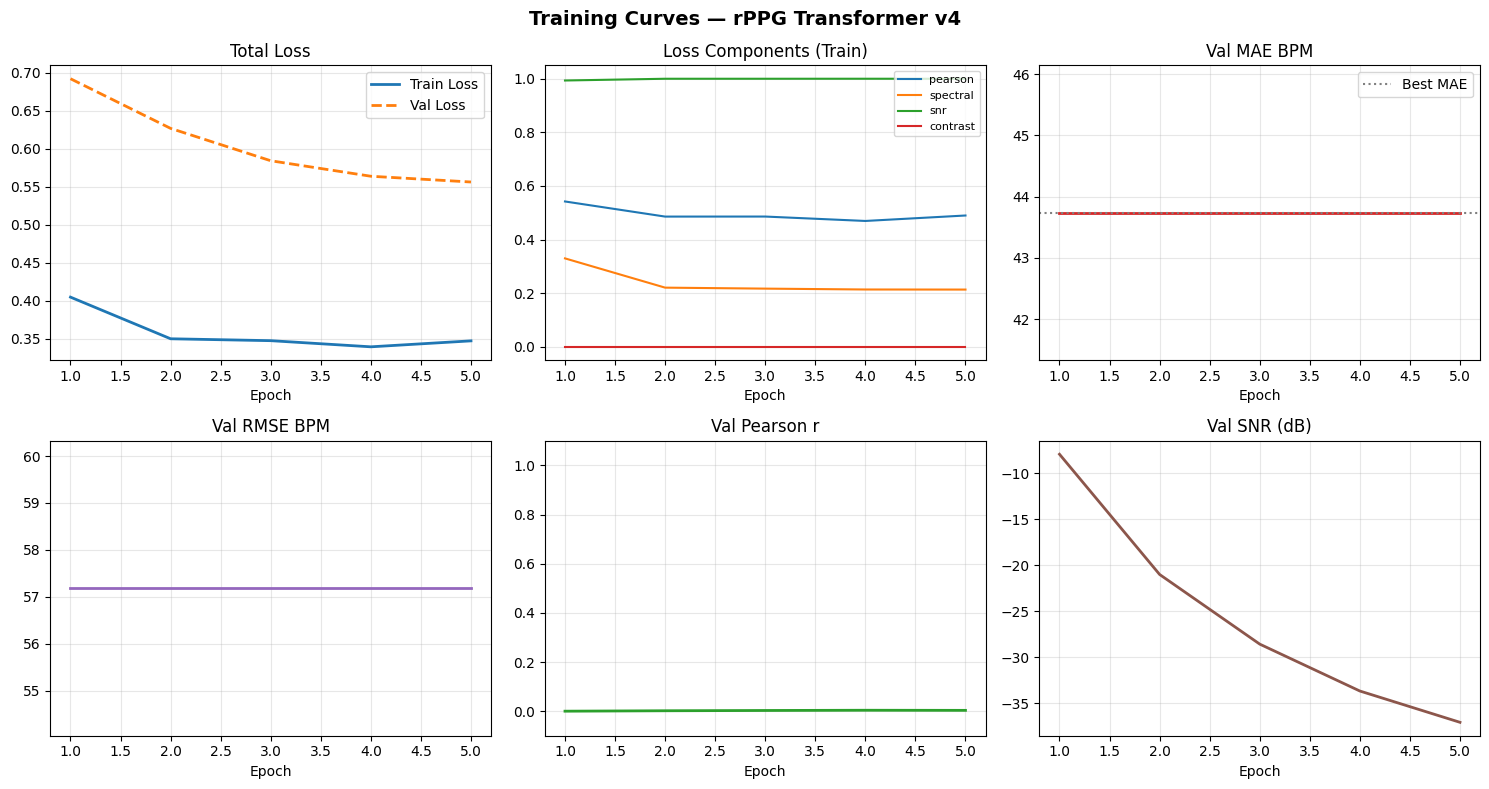

Saved → checkpoints\training_curves.png


In [41]:
def plot_training_curves(train_history: list, val_history: list) -> None:
    """Plot loss and BPM metrics over epochs."""
    epochs = list(range(1, len(train_history) + 1))

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Training Curves — rPPG Transformer v4", fontsize=14, fontweight='bold')

    # Train / Val loss
    ax = axes[0, 0]
    ax.plot(epochs, [h['total']    for h in train_history], label='Train Loss', lw=2)
    ax.plot(epochs, [h.get('val_loss', np.nan) for h in val_history],
            label='Val Loss', lw=2, linestyle='--')
    ax.set_title("Total Loss"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

    # Loss components
    ax = axes[0, 1]
    for k, color in [('pearson','tab:blue'),('spectral','tab:orange'),
                     ('snr','tab:green'),('contrast','tab:red')]:
        ax.plot(epochs, [h.get(k, np.nan) for h in train_history],
                label=k, lw=1.5, color=color)
    ax.set_title("Loss Components (Train)"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # MAE BPM
    ax = axes[0, 2]
    mae_vals = [h.get('mae_bpm', np.nan) for h in val_history]
    ax.plot(epochs, mae_vals, lw=2, color='tab:red')
    ax.axhline(min([v for v in mae_vals if not np.isnan(v)] or [0]),
               color='grey', linestyle=':', label=f'Best MAE')
    ax.set_title("Val MAE BPM"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

    # RMSE BPM
    ax = axes[1, 0]
    ax.plot(epochs, [h.get('rmse_bpm', np.nan) for h in val_history], lw=2, color='tab:purple')
    ax.set_title("Val RMSE BPM"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)

    # Pearson r
    ax = axes[1, 1]
    ax.plot(epochs, [h.get('pearson_r', np.nan) for h in val_history], lw=2, color='tab:green')
    ax.set_ylim([-0.1, 1.1])
    ax.set_title("Val Pearson r"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)

    # SNR
    ax = axes[1, 2]
    ax.plot(epochs, [h.get('snr_db', np.nan) for h in val_history], lw=2, color='tab:brown')
    ax.set_title("Val SNR (dB)"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(cfg.CKPT_DIR) / "training_curves.png", dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved → {Path(cfg.CKPT_DIR)/'training_curves.png'}")

plot_training_curves(train_history, val_history)


## 📈 Evaluation Plots
- **BPM Scatter**: Predicted vs Ground-Truth BPM
- **Bland-Altman**: Agreement analysis (clinical standard)
- **FFT Spectrum**: Frequency-domain prediction vs GT


In [42]:
def bland_altman_plot(
    pred_bpms: np.ndarray,
    gt_bpms:   np.ndarray,
    title:     str = "Bland-Altman",
) -> None:
    """
    Bland-Altman agreement plot.
    Differences (pred - GT) vs means are shown with 95% LoA.
    """
    means = (pred_bpms + gt_bpms) / 2
    diffs = pred_bpms - gt_bpms
    bias  = diffs.mean()
    std   = diffs.std()
    loa   = 1.96 * std

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Scatter plot
    ax = axes[0]
    ax.scatter(gt_bpms, pred_bpms, alpha=0.7, edgecolors='k', linewidths=0.5, s=60)
    lims = [min(gt_bpms.min(), pred_bpms.min()) - 5,
            max(gt_bpms.max(), pred_bpms.max()) + 5]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Identity')
    ax.set_xlabel("GT BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"Scatter  MAE={np.abs(diffs).mean():.2f} BPM")
    ax.legend(); ax.grid(True, alpha=0.3)

    # Bland-Altman
    ax = axes[1]
    ax.scatter(means, diffs, alpha=0.7, edgecolors='k', linewidths=0.5, s=60)
    ax.axhline(bias,        color='blue',  lw=2, linestyle='-',  label=f'Bias={bias:.2f}')
    ax.axhline(bias + loa,  color='red',   lw=1.5, linestyle='--', label=f'+1.96σ={bias+loa:.2f}')
    ax.axhline(bias - loa,  color='red',   lw=1.5, linestyle='--', label=f'-1.96σ={bias-loa:.2f}')
    ax.set_xlabel("Mean BPM"); ax.set_ylabel("Difference (Pred - GT)")
    ax.set_title(f"Bland-Altman  Bias={bias:.2f}  LoA=±{loa:.2f}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(cfg.CKPT_DIR) / "bland_altman.png", dpi=120, bbox_inches='tight')
    plt.show()


def plot_signal_comparison(
    pred_signal: np.ndarray,
    gt_signal:   np.ndarray,
    fs:          float = 30.0,
    title:       str   = "Signal Comparison",
) -> None:
    """Plot time-domain and frequency-domain comparison of predicted vs GT signal."""
    N     = min(len(pred_signal), len(gt_signal))
    t     = np.arange(N) / fs
    p     = bandpass_filter(pred_signal[:N], fs)
    g     = bandpass_filter(gt_signal[:N],   fs)

    freqs = np.fft.rfftfreq(N, d=1.0/fs) * 60   # in BPM
    P_fft = np.abs(np.fft.rfft(p * np.hanning(N)))
    G_fft = np.abs(np.fft.rfft(g * np.hanning(N)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    ax = axes[0]
    ax.plot(t, g, lw=1.5, label='GT BVP',    alpha=0.9)
    ax.plot(t, p, lw=1.5, label='Predicted', alpha=0.8, linestyle='--')
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Normalised Signal")
    ax.set_title("Time Domain"); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    bpm_mask = (freqs >= BPM_LOW) & (freqs <= BPM_HIGH)
    ax.plot(freqs[bpm_mask], G_fft[bpm_mask], lw=2, label='GT BVP')
    ax.plot(freqs[bpm_mask], P_fft[bpm_mask], lw=2, label='Predicted', linestyle='--')
    bpm_gt   = compute_bpm(g, fs)
    bpm_pred = compute_bpm(p, fs)
    ax.axvline(bpm_gt,   color='blue',  linestyle=':', lw=1.5, label=f'GT BPM={bpm_gt:.1f}')
    ax.axvline(bpm_pred, color='orange',linestyle=':', lw=1.5, label=f'Pred BPM={bpm_pred:.1f}')
    ax.set_xlabel("BPM"); ax.set_ylabel("FFT Magnitude")
    ax.set_title("Frequency Domain (BPM band)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(cfg.CKPT_DIR) / "signal_comparison.png", dpi=120, bbox_inches='tight')
    plt.show()


print("Visualisation functions ready: bland_altman_plot, plot_signal_comparison")


Visualisation functions ready: bland_altman_plot, plot_signal_comparison


## 🎯 Full Evaluation on Best Model
Load best checkpoint (EMA weights), run inference on full validation set,
compute all metrics, and display plots.


Loaded EMA weights from checkpoints\best_rppg_v4.pth  (epoch 1)


Evaluating best model: 100%|█████████████████████████████████████████████████████████| 236/236 [03:45<00:00,  1.05it/s]



  FINAL EVALUATION METRICS (Best Checkpoint — EMA)
  MAE BPM      : 43.74 BPM
  RMSE BPM     : 57.18 BPM
  Pearson r    : -0.0002
  Mean SNR     : -7.94 dB


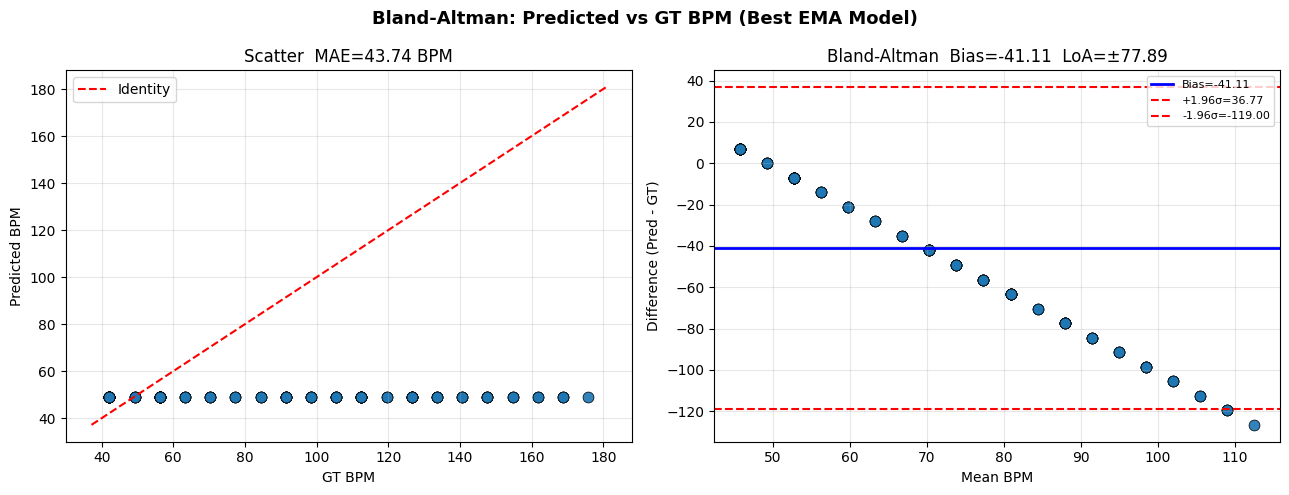

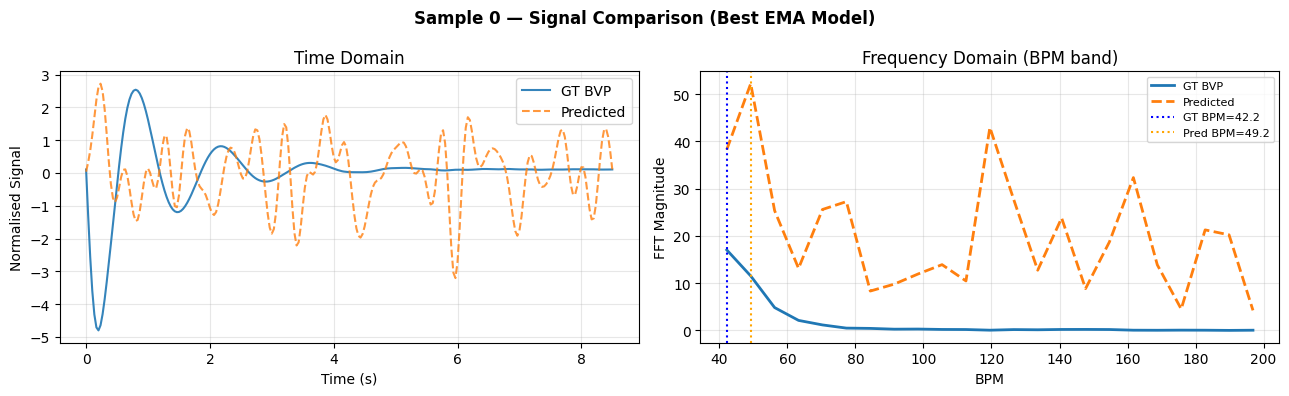

In [43]:
def load_best_model(path: str) -> None:
    """Load EMA weights from best checkpoint into model."""
    ckpt = torch.load(path, map_location=cfg.DEVICE)
    if 'ema_state' in ckpt:
        model.load_state_dict(
            {k: v.to(cfg.DEVICE) for k, v in ckpt['ema_state'].items()}
        )
        print(f"Loaded EMA weights from {path}  (epoch {ckpt.get('epoch','?')})")
    else:
        model.load_state_dict(ckpt['model_state'])
        print(f"Loaded model weights from {path}")


best_ckpt = Path(cfg.CKPT_DIR) / cfg.SAVE_BEST
if best_ckpt.exists():
    load_best_model(str(best_ckpt))

# ── Run full validation ────────────────────────────────────────────────────
model.eval()
all_preds, all_gts = [], []

with torch.no_grad():
    for diff, raw, sig, mask in tqdm(val_loader, desc="Evaluating best model"):
        diff = diff.to(cfg.DEVICE); raw  = raw.to(cfg.DEVICE)
        sig  = sig.to(cfg.DEVICE);  mask = mask.to(cfg.DEVICE)
        with autocast(enabled=cfg.USE_AMP):
            pred = model(diff, raw, src_key_padding_mask=(mask==0))
        for b in range(pred.shape[0]):
            vl = int(mask[b].sum().item())
            if vl > 16:
                all_preds.append(pred[b, :vl].cpu().numpy())
                all_gts.append(sig[b,  :vl].cpu().numpy())

if len(all_preds) == 0:
    print("⚠️  No valid predictions — check validation set.")
else:
    min_len   = min(len(p) for p in all_preds)
    preds_arr = np.stack([p[:min_len] for p in all_preds])
    gts_arr   = np.stack([g[:min_len] for g in all_gts])
    final_m   = compute_metrics(preds_arr, gts_arr, cfg.FPS)

    print("\n" + "="*55)
    print("  FINAL EVALUATION METRICS (Best Checkpoint — EMA)")
    print("="*55)
    print(f"  MAE BPM      : {final_m['mae_bpm']:.2f} BPM")
    print(f"  RMSE BPM     : {final_m['rmse_bpm']:.2f} BPM")
    print(f"  Pearson r    : {final_m['pearson_r']:.4f}")
    print(f"  Mean SNR     : {final_m['snr_db']:.2f} dB")
    print("="*55)

    bland_altman_plot(final_m['pred_bpms'], final_m['gt_bpms'],
                      title="Bland-Altman: Predicted vs GT BPM (Best EMA Model)")

    if len(all_preds) > 0:
        plot_signal_comparison(all_preds[0], all_gts[0], cfg.FPS,
                               title="Sample 0 — Signal Comparison (Best EMA Model)")


## 🚀 Deployment-Ready Inference
`rppg_inference` is a self-contained function that:
1. Opens a video (file or webcam stream)
2. Extracts frames → ROI
3. Runs the model in streaming windows
4. Returns BPM estimate + rPPG waveform

Suitable for real-time use — processes one `SEQ_LEN` window at a time.


In [44]:
@torch.no_grad()
def rppg_inference(
    source,            # str path or int webcam index
    model:    nn.Module = None,
    fs:       float   = 30.0,
    seq_len:  int     = None,
    device:   str     = None,
    verbose:  bool    = True,
) -> dict:
    """
    End-to-end rPPG inference on a video file or webcam.

    Parameters
    ----------
    source    : str (video file path) or int (webcam index, e.g. 0)
    model     : RPPGTransformer instance (uses global `model` if None)
    fs        : frames per second of the source video
    seq_len   : window size for inference (defaults to cfg.SEQ_LEN)
    device    : 'cuda' or 'cpu' (defaults to cfg.DEVICE)
    verbose   : print BPM result

    Returns
    -------
    dict with keys:
        'bpm'       : float  — dominant BPM
        'signal'    : np.ndarray (N,) — predicted rPPG waveform
        'bpm_conf'  : float  — spectral confidence in [0,1]
        'snr_db'    : float  — SNR of predicted signal
    """
    import warnings
    from contextlib import suppress

    _model    = model  or globals()['model']
    _device   = device or cfg.DEVICE
    _seq_len  = seq_len or cfg.SEQ_LEN
    _model.eval().to(_device)

    face_mesh  = get_face_mesh()
    stabiliser = LandmarkStabiliser(alpha=0.65)
    cap        = cv2.VideoCapture(source)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video source: {source}")

    raw_buf, diff_buf = [], []
    all_pred_signal   = []

    prev_frame = None

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        results   = face_mesh.process(frame_rgb)
        if not results.multi_face_landmarks:
            continue

        lm   = results.multi_face_landmarks[0]
        rois = []
        for ridx, idxs in enumerate([FOREHEAD_IDXS, LEFT_CHEEK, RIGHT_CHEEK]):
            roi_img, _, _ = extract_roi(
                frame_rgb, lm, idxs,
                stabiliser=stabiliser, roi_idx=ridx, img_size=cfg.IMG_SIZE
            )
            if roi_img is not None:
                rois.append(roi_img)

        if not rois:
            continue

        face = np.mean(np.stack(rois), axis=0).astype(np.float32)
        raw_buf.append(face)

        if prev_frame is not None:
            diff = face - prev_frame
            diff = (diff - diff.mean()) / (diff.std() + 1e-8)
            diff_buf.append(diff.astype(np.float32))
        prev_frame = face

        # Process window
        if len(diff_buf) == _seq_len:
            diff_t = torch.tensor(
                np.stack(diff_buf)[np.newaxis], dtype=torch.float32
            ).to(_device)
            raw_t  = torch.tensor(
                np.stack(raw_buf[1:_seq_len+1])[np.newaxis], dtype=torch.float32
            ).to(_device)

            with autocast(enabled=cfg.USE_AMP):
                pred = _model(diff_t, raw_t).squeeze(0).cpu().numpy()

            all_pred_signal.extend(pred.tolist())
            # Slide by half window
            step = _seq_len // 2
            diff_buf = diff_buf[step:]
            raw_buf  = raw_buf[step:]

    cap.release()

    if len(all_pred_signal) < 16:
        return {'bpm': 75.0, 'signal': np.array([]), 'bpm_conf': 0.0, 'snr_db': -99.0}

    sig  = bandpass_filter(np.array(all_pred_signal, dtype=np.float32), fs)
    bpm  = compute_bpm(sig, fs)
    snr  = compute_snr(sig, fs)

    # BPM confidence: normalised peak height
    freqs   = np.fft.rfftfreq(len(sig), d=1.0/fs)
    fft_mag = np.abs(np.fft.rfft(sig * np.hanning(len(sig))))
    band    = (freqs >= FREQ_LOW) & (freqs <= FREQ_HIGH)
    with suppress(Exception):
        conf = float(fft_mag[band].max() / (fft_mag[band].mean() + 1e-8))
        conf = min(conf / 10.0, 1.0)   # normalise to [0,1]
    else:
        conf = 0.0

    if verbose:
        print(f"rPPG Inference complete")
        print(f"  BPM estimate : {bpm:.1f}  (confidence={conf:.2f})")
        print(f"  Signal SNR   : {snr:.1f} dB")
        print(f"  Signal length: {len(sig)} frames  ({len(sig)/fs:.1f}s)")

    return {'bpm': bpm, 'signal': sig, 'bpm_conf': conf, 'snr_db': snr}


print("rppg_inference() ready.")
print("  Usage: result = rppg_inference('path/to/video.avi')")
print("         result = rppg_inference(0)  # webcam")


SyntaxError: invalid syntax (4089424719.py, line 116)

## 📦 ONNX Export (Edge Deployment Stub)
Export the trained model to ONNX for deployment on edge devices (e.g. Jetson Nano, mobile).


In [ ]:
def export_onnx(
    model:     nn.Module,
    save_path: str = "rppg_model.onnx",
    seq_len:   int = None,
    img_size:  int = None,
) -> None:
    """
    Export RPPGTransformer to ONNX format for edge deployment.

    Notes
    -----
    - Uses dynamic axes for batch and sequence dimensions.
    - Disables gradient checkpointing before export.
    - Requires opset 17+ for dynamic shapes with Transformer.
    """
    _seq  = seq_len  or cfg.SEQ_LEN
    _img  = img_size or cfg.IMG_SIZE

    # Temporarily disable grad checkpointing (incompatible with ONNX trace)
    original_grad_ckpt = cfg.GRAD_CKPT
    cfg.GRAD_CKPT = False
    model.eval()

    dummy_diff = torch.randn(1, _seq, _img, _img, 3)
    dummy_raw  = torch.randn(1, _seq, _img, _img, 3)

    try:
        torch.onnx.export(
            model,
            (dummy_diff, dummy_raw),
            save_path,
            opset_version=17,
            input_names=['diff_frames', 'raw_frames'],
            output_names=['rppg_signal'],
            dynamic_axes={
                'diff_frames': {0: 'batch', 1: 'seq_len'},
                'raw_frames':  {0: 'batch', 1: 'seq_len'},
                'rppg_signal': {0: 'batch', 1: 'seq_len'},
            },
            do_constant_folding=True,
        )
        print(f"✅  ONNX model exported to: {save_path}")
        print(f"    Input  : diff_frames (B, T, {_img}, {_img}, 3)")
        print(f"    Input  : raw_frames  (B, T, {_img}, {_img}, 3)")
        print(f"    Output : rppg_signal (B, T)")
    except Exception as e:
        print(f"⚠️  ONNX export failed: {e}")
        print("    This is expected if the model contains unsupported ops.")
        print("    Consider using TorchScript (torch.jit.trace) as an alternative.")
    finally:
        cfg.GRAD_CKPT = original_grad_ckpt


# Uncomment to export:
# export_onnx(model, save_path=str(Path(cfg.CKPT_DIR)/"rppg_model.onnx"))
print("ONNX export function defined. Uncomment the last line to export.")


## 🔬 Self-Supervised Pre-training (Contrastive)
Full SimCLR-style pre-training loop stub.
Fine-tune the backbone on unlabelled face videos before supervised training.


In [ ]:
class ContrastiveRPPGHead(nn.Module):
    """
    MLP projection head for self-supervised rPPG pre-training.

    Usage (pseudo-code):
    --------------------
    backbone = RPPGTransformer()
    head     = ContrastiveRPPGHead(cfg.D_MODEL)

    for vid_a, vid_b in unlabelled_pairs:
        z_a = head(backbone(vid_a, vid_a).mean(dim=1))  # pool over time
        z_b = head(backbone(vid_b, vid_b).mean(dim=1))
        loss = nt_xent_loss(z_a, z_b)
        loss.backward()
    """
    def __init__(self, d_model: int = 128, proj_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, D) → (B, D) by mean-pooling → (B, proj_dim)
        return F.normalize(self.net(x.mean(dim=1)), dim=1)


def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    """NT-Xent (SimCLR) contrastive loss for two augmented views."""
    B    = z1.shape[0]
    z    = torch.cat([z1, z2], dim=0)                        # (2B, D)
    sim  = torch.mm(z, z.T) / temperature                    # (2B, 2B)
    mask = torch.eye(2*B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))
    labels = torch.cat([
        torch.arange(B, 2*B, device=z.device),
        torch.arange(0, B,   device=z.device)
    ])
    return F.cross_entropy(sim, labels)


print("Self-supervised pre-training components ready:")
print("  ContrastiveRPPGHead, nt_xent_loss")


## 🔭 Research-Level Analysis & Future Improvements

### Remaining Weaknesses

| Issue | Description | Severity |
|-------|-------------|----------|
| Domain gap | Trained only on UBFC-rPPG (indoor, static) | High |
| Short clips | SEQ_LEN=256 at 30fps = ~8.5s — misses slow HR changes | Medium |
| Skin mask heuristic | YCrCb thresholds fail on dark skin tones | Medium |
| No temporal interpolation | Dropped frames cause discontinuities | Medium |
| Single-dataset eval | No cross-dataset generalisation test | High |

---

### Performance Bottlenecks (Ranked by Impact)

1. **CNN encoder size** — MultiScaleSpatialEncoder is compute-heavy. Replace with MobileNetV3 or ShuffleNetV2 pretrained backbone.
2. **Frame-level processing** — Still runs per-frame CNN. PhysFormer uses tube (3D patch) embeddings which capture temporal context inside the CNN stage.
3. **Fixed FPS assumption** — Real-world cameras vary between 15–120fps. Implement temporal resampling.
4. **SEQ_LEN = 256** — Transformers scale O(T²) in attention. Use Longformer / Linformer for longer context.

---

### Advanced Future Improvements

```
Priority 1 (High impact, medium effort)
  ✦ Replace CNN with EfficientPhys-style 3D spatiotemporal tubes
  ✦ Multi-dataset training: UBFC + MAHNOB + PURE + COHFACE
  ✦ Leave-One-Out cross-validation (standard in rPPG literature)
  ✦ Data normalisation: per-subject mean-subtraction of BVP

Priority 2 (High impact, high effort)
  ✦ PhysFormer full architecture (cross-attention between RGB patches and temporal queries)
  ✦ BYOL / MoCo v3 self-supervised pre-training on face videos
  ✦ Domain adaptation with DANN or MMD between lab datasets and in-the-wild

Priority 3 (Medium impact)
  ✦ Real-time streaming inference (ring buffer + ONNX Runtime)
  ✦ Skin tone-aware training (balanced sampling across Fitzpatrick scale)
  ✦ Multimodal: fuse RGB with NIR channel (when available)
  ✦ Emotion integration: BPM + HRV features → arousal/valence prediction
```

---

### Latest Applicable Research Techniques

| Paper | Key Idea | Applicable Here |
|-------|----------|----------------|
| PhysFormer (CVPR22) | Temporal difference transformer with frequency supervision | Partially implemented |
| EfficientPhys (CVPR23) | Standard mean + std pooling + pure Transformer, no CNN | Replace CNN encoder |
| rPPG-MAE (2023) | Masked autoencoder pre-training on face tubes | SSL pre-training |
| BVPNet (2022) | Auxiliary depth map for better ROI quality | With depth camera |
| NEST-rPPG (2024) | Noise-equivariant self-supervised training | No labels needed |

---

### Edge Deployment Optimisation

```python
# TensorRT optimisation (after ONNX export)
import tensorrt as trt
# FP16 quantisation reduces latency by ~2× on Jetson
# INT8 calibration reduces latency by ~4× with ~5% accuracy drop

# TorchScript (no ONNX needed)
traced = torch.jit.trace(model, (dummy_diff, dummy_raw))
traced.save("rppg_scripted.pt")

# PyTorch Mobile
from torch.utils.mobile_optimizer import optimize_for_mobile
mobile_model = optimize_for_mobile(traced)
mobile_model._save_for_lite_interpreter("rppg_mobile.ptl")
```

---

### Common Failure Cases & Fixes

| Failure | Symptom | Fix |
|---------|---------|-----|
| BPM stuck at 75 | Model predicts flat signal | Check GT signal length alignment |
| NaN loss at epoch 1 | Exploding gradients | Reduce LR; check for NaN in GT file |
| val MAE > 30 BPM | Poor generalisation | More data; stronger augmentation |
| Face detection fails | All frames skipped | Lower `min_detection_confidence` to 0.5 |
| CLAHE over-sharpens | Noisy ROI | Set `apply_clahe=False` for dark environments |
| Memory OOM | CUDA out of memory | Reduce `IMG_SIZE` to 32; enable `GRAD_CKPT` |

---

### Training Tips

1. **Always inspect GT BVP signals** with `plot_signal_comparison` before training — corrupt files cause silent NaN propagation.
2. **Start with `SEQ_LEN=128`** for rapid iteration, then increase to 256 for final training.
3. **Monitor `snr_db` metric** — it plateaus before MAE, indicating the model has learned spectral structure before fine-grained waveform alignment.
4. **Use 5-fold cross-validation** for UBFC (42 subjects) — any single 80/20 split has high variance.
5. **Gradient norm tracking** — if `grad_norm > 5` frequently, reduce LR or increase `ACCUM_STEPS`.
